In [1]:
print ("annyeosagho")

annyeosagho


In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
df = pd.read_csv("Hypertension_Cardiology_Center_Dataset.csv")

df.head()

,Patient_ID,Age,Age_Group,Gender,Diabetes_Mellitus,Chronic_Kidney_Disease,Dyslipidemia,Obesity,Baseline_Systolic_BP,Baseline_Diastolic_BP,Antihypertensive_Class,Medication_Adherence,Followup_Systolic_BP,Followup_Diastolic_BP,BP_Systolic_Reduction,BP_Diastolic_Reduction,BP_Controlled_After_3_Months,Number_of_Visits,Registration_Date
0,HTN0001,70,70-79,Male,Yes,No,Yes,Yes,148,113,ACE Inhibitor,Poor,142,110,6,3,No,1,16/01/2024
1,HTN0002,35,30-39,Male,Yes,Yes,Yes,No,154,104,Beta Blocker,Moderate,144,98,10,6,No,3,22/05/2024
2,HTN0003,39,30-39,Male,No,Yes,Yes,No,146,101,Calcium Channel Blocker,Poor,139,97,7,4,No,5,04/03/2024
3,HTN0004,54,50-59,Male,No,No,Yes,Yes,142,111,ARB,Moderate,131,105,11,6,No,4,22/05/2024
4,HTN0005,59,50-59,Female,Yes,No,No,Yes,182,98,Combination Therapy,Poor,166,89,16,9,No,5,05/05/2024


In [4]:
#create target variable
df['BP_Failure'] = df['BP_Controlled_After_3_Months'].map({
    'Yes': 0,
    'No': 1})

In [5]:
#at the point of prescription, so we will be using only the features the patient has before prescription
features = ["Age", "Age_Group", "Gender", "Diabetes_Mellitus", "Chronic_Kidney_Disease", "Dyslipidemia", "Obesity", 
            "Baseline_Systolic_BP", "Baseline_Diastolic_BP", "Antihypertensive_Class", "Medication_Adherence", 
            "Number_of_Visits"]

X = df[features]
y = df["BP_Failure"]

In [6]:
#splitting columns into categorical and numeric columns
categorical_columns = ["Age_Group", "Gender", "Diabetes_Mellitus", "Chronic_Kidney_Disease", "Dyslipidemia",
                       "Obesity", "Antihypertensive_Class", "Medication_Adherence"]

numeric_columns = ["Age", "Baseline_Systolic_BP", "Baseline_Diastolic_BP", "Number_of_Visits"]

In [7]:
#building model
preprocessor = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_columns),
                  ("num", "passthrough", numeric_columns)])

model = Pipeline(
    steps=[("preprocessor", preprocessor), ("classifier", LogisticRegression(max_iter=1000))])

In [8]:
#training model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [9]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9285714285714286
[[ 2  5]
 [ 0 63]]
              precision    recall  f1-score   support

           0       1.00      0.29      0.44         7
           1       0.93      1.00      0.96        63

    accuracy                           0.93        70
   macro avg       0.96      0.64      0.70        70
weighted avg       0.93      0.93      0.91        70



In [10]:
#identifying high risk patients
df["Failure_Risk_Probability"] = model.predict_proba(X)[:, 1]

df["Risk_Level"] = np.where(
    df["Failure_Risk_Probability"] >= 0.70,
    "High Risk",
    np.where(df["Failure_Risk_Probability"] >= 0.40, "Moderate Risk", "Low Risk")
)

df[["Patient_ID", "Failure_Risk_Probability", "Risk_Level"]].head(10)

,Patient_ID,Failure_Risk_Probability,Risk_Level
0,HTN0001,0.998398,High Risk
1,HTN0002,0.975817,High Risk
2,HTN0003,0.980177,High Risk
3,HTN0004,0.982086,High Risk
4,HTN0005,0.999817,High Risk
5,HTN0006,0.999994,High Risk
6,HTN0007,0.308166,Low Risk
7,HTN0008,0.134824,Low Risk
8,HTN0009,0.477672,Moderate Risk
9,HTN0010,0.999934,High Risk


In [25]:
df.to_csv("Hypertension_Cardiology_Scored.csv", index=False)

In [11]:
#top high risk patients
high_risk_patients = df[
    df["Risk_Level"] == "High Risk"
].sort_values(by="Failure_Risk_Probability", ascending=False)

high_risk_patients[
    ["Patient_ID", "Age", "Gender", "Antihypertensive_Class", 
     "Medication_Adherence", "Failure_Risk_Probability", "Risk_Level"]
].head(10)

,Patient_ID,Age,Gender,Antihypertensive_Class,Medication_Adherence,Failure_Risk_Probability,Risk_Level
293,HTN0294,37,Male,Calcium Channel Blocker,Poor,1.000000,High Risk
179,HTN0180,44,Male,Calcium Channel Blocker,Poor,1.000000,High Risk
151,HTN0152,83,Male,Calcium Channel Blocker,Good,1.000000,High Risk
177,HTN0178,53,Female,ACE Inhibitor,Poor,1.000000,High Risk
46,HTN0047,30,Female,Thiazide Diuretic,Poor,1.000000,High Risk
74,HTN0075,73,Male,Thiazide Diuretic,Poor,1.000000,High Risk
282,HTN0283,56,Female,Thiazide Diuretic,Moderate,1.000000,High Risk
270,HTN0271,56,Female,ARB,Poor,1.000000,High Risk
297,HTN0298,58,Male,Beta Blocker,Poor,1.000000,High Risk
65,HTN0066,56,Male,ARB,Moderate,0.999999,High Risk


ROC AUC: 0.9546485260770975


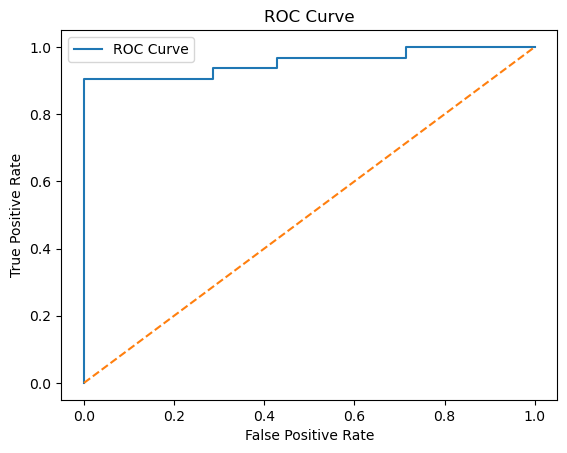

In [12]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

y_prob = model.predict_proba(X_test)[:, 1]

# AUC
print("ROC AUC:", roc_auc_score(y_test, y_prob))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

blue_palette = ["#0B3C5D", "#1D6FA5", "#3A9AD9", "#74BDE0", "#B7DFF2"]

C:\Users\User\AppData\Local\Temp\ipykernel_8852\3761771805.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
C:\Users\User\AppData\Local\Temp\ipykernel_8852\3761771805.py:3: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  ax = sns.countplot(


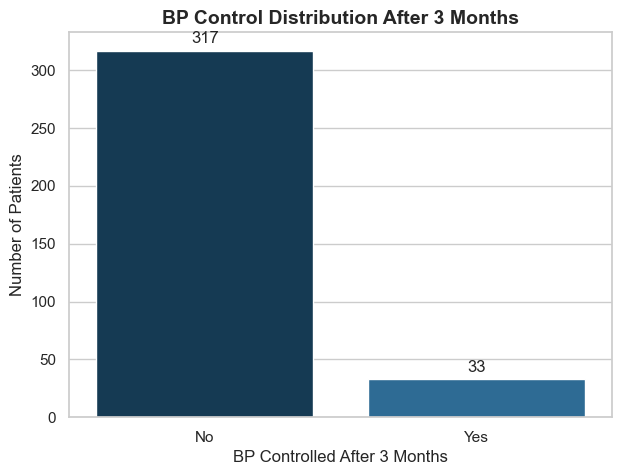

In [14]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=df,
    x="BP_Controlled_After_3_Months",
    palette=blue_palette
)

plt.title("BP Control Distribution After 3 Months", fontsize=14, fontweight="bold")
plt.xlabel("BP Controlled After 3 Months")
plt.ylabel("Number of Patients")

for container in ax.containers:
    ax.bar_label(container, fmt="%d", label_type="edge", padding=3)

plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_8852\2091047168.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
C:\Users\User\AppData\Local\Temp\ipykernel_8852\2091047168.py:6: UserWarning: 
The palette list has fewer values (5) than needed (6) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(


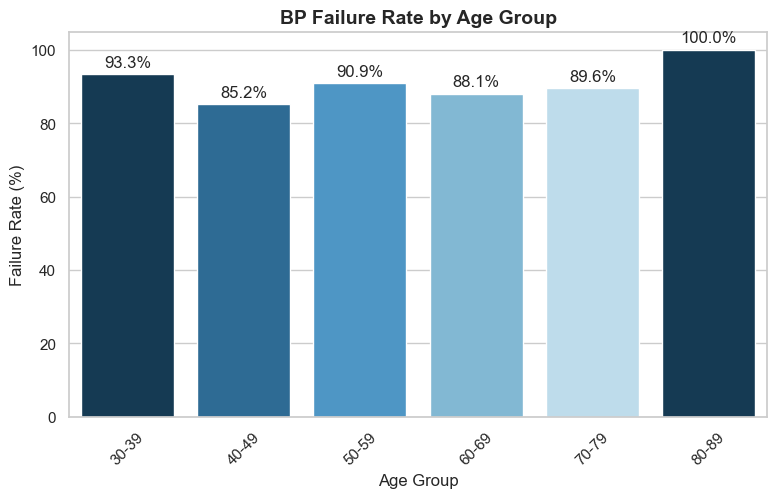

In [15]:
age_failure = df.groupby("Age_Group")["BP_Failure"].mean().reset_index()
age_failure["Failure_Rate"] = age_failure["BP_Failure"] * 100

plt.figure(figsize=(9,5))

ax = sns.barplot(
    data=age_failure,
    x="Age_Group",
    y="Failure_Rate",
    palette=blue_palette
)

plt.title("BP Failure Rate by Age Group", fontsize=14, fontweight="bold")
plt.xlabel("Age Group")
plt.ylabel("Failure Rate (%)")
plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="edge", padding=3)

plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_8852\2506354562.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
C:\Users\User\AppData\Local\Temp\ipykernel_8852\2506354562.py:18: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  ax = sns.barplot(


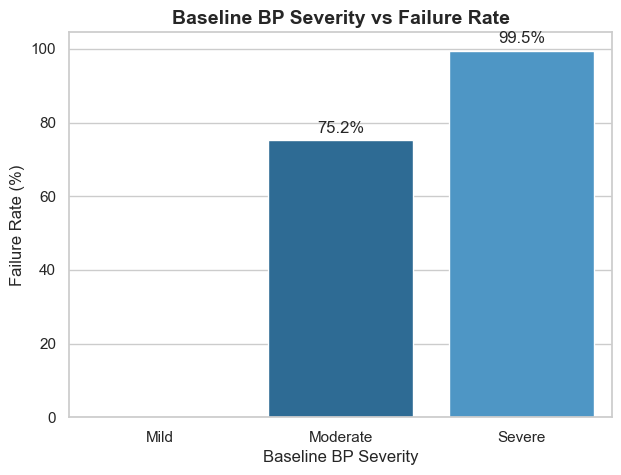

In [16]:
def bp_severity(row):
    if row["Baseline_Systolic_BP"] >= 160:
        return "Severe"
    elif row["Baseline_Systolic_BP"] >= 140:
        return "Moderate"
    else:
        return "Mild"

df["BP_Level"] = df.apply(bp_severity, axis=1)

severity_failure = df.groupby("BP_Level")["BP_Failure"].mean().reset_index()
severity_failure["Failure_Rate"] = severity_failure["BP_Failure"] * 100

order = ["Mild", "Moderate", "Severe"]

plt.figure(figsize=(7,5))

ax = sns.barplot(
    data=severity_failure,
    x="BP_Level",
    y="Failure_Rate",
    order=order,
    palette=blue_palette
)

plt.title("Baseline BP Severity vs Failure Rate", fontsize=14, fontweight="bold")
plt.xlabel("Baseline BP Severity")
plt.ylabel("Failure Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="edge", padding=3)

plt.show()

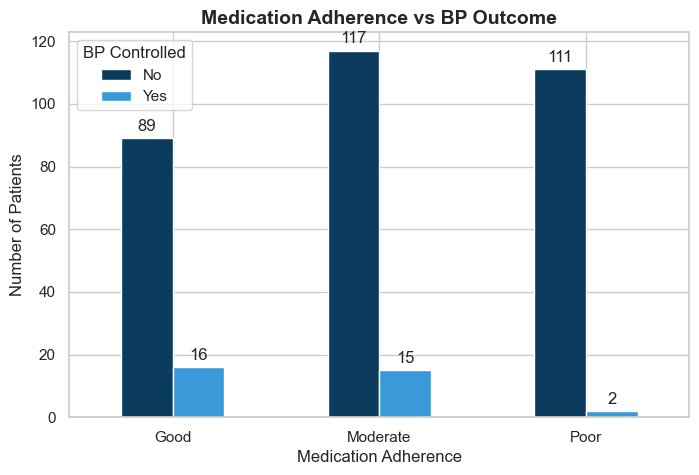

In [17]:
adherence_outcome = pd.crosstab(
    df["Medication_Adherence"],
    df["BP_Controlled_After_3_Months"]
)

ax = adherence_outcome.plot(
    kind="bar",
    figsize=(8,5),
    color=["#0B3C5D", "#3A9AD9"]
)

plt.title("Medication Adherence vs BP Outcome", fontsize=14, fontweight="bold")
plt.xlabel("Medication Adherence")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.legend(title="BP Controlled")

for container in ax.containers:
    ax.bar_label(container, fmt="%d", label_type="edge", padding=3)

plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_8852\3024043589.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  drug_control = df.groupby("Antihypertensive_Class").apply(
C:\Users\User\AppData\Local\Temp\ipykernel_8852\3024043589.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
C:\Users\User\AppData\Local\Temp\ipykernel_8852\3024043589.py:9: UserWarning: 
The palette list has fewer values (5) than needed (6) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(


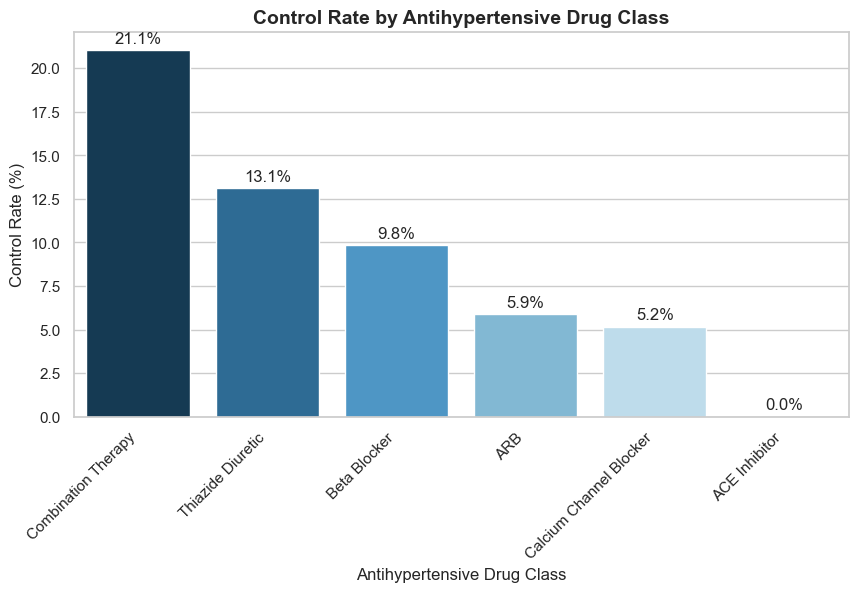

In [18]:
drug_control = df.groupby("Antihypertensive_Class").apply(
    lambda x: (x["BP_Controlled_After_3_Months"] == "Yes").mean() * 100
).reset_index(name="Control_Rate")

drug_control = drug_control.sort_values("Control_Rate", ascending=False)

plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=drug_control,
    x="Antihypertensive_Class",
    y="Control_Rate",
    palette=blue_palette
)

plt.title("Control Rate by Antihypertensive Drug Class", fontsize=14, fontweight="bold")
plt.xlabel("Antihypertensive Drug Class")
plt.ylabel("Control Rate (%)")
plt.xticks(rotation=45, ha="right")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="edge", padding=3)

plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_8852\866237779.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  temp = df[df[condition] == "Yes"].groupby("Antihypertensive_Class").apply(
C:\Users\User\AppData\Local\Temp\ipykernel_8852\866237779.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  temp = df[df[condition] == "Yes"].groupby("Antihypertensive_Class").apply(
C:\Users\User\AppData\Local\Temp\ipykernel_8852\

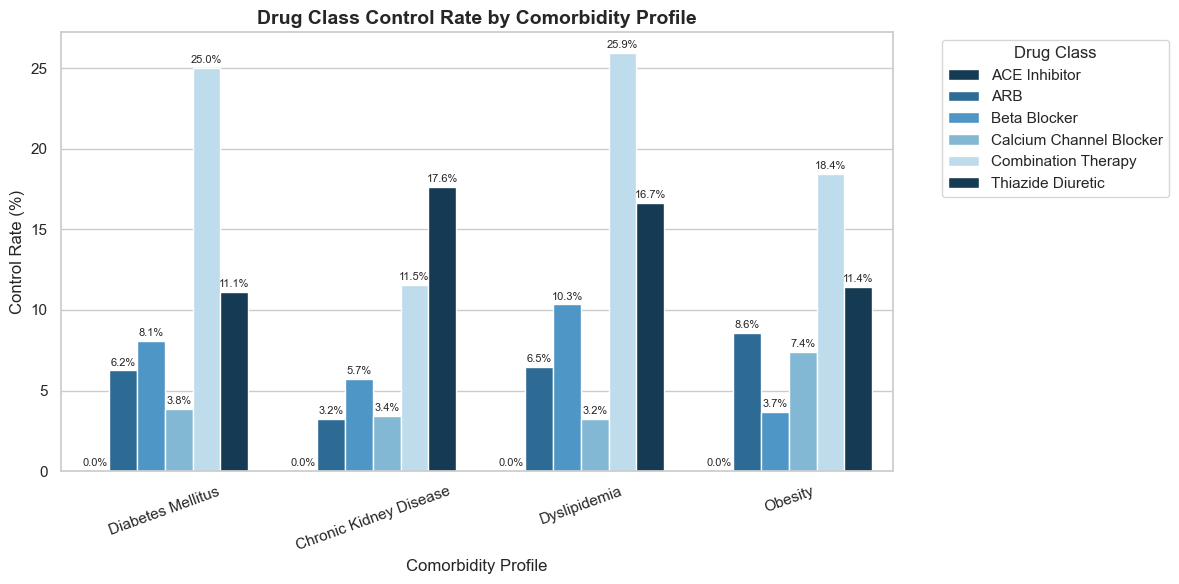

In [19]:
comorbidity_cols = [
    "Diabetes_Mellitus",
    "Chronic_Kidney_Disease",
    "Dyslipidemia",
    "Obesity"
]

comorbidity_results = []

for condition in comorbidity_cols:
    temp = df[df[condition] == "Yes"].groupby("Antihypertensive_Class").apply(
        lambda x: (x["BP_Controlled_After_3_Months"] == "Yes").mean() * 100
    ).reset_index(name="Control_Rate")
    
    temp["Comorbidity"] = condition.replace("_", " ")
    comorbidity_results.append(temp)

comorbidity_df = pd.concat(comorbidity_results)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=comorbidity_df,
    x="Comorbidity",
    y="Control_Rate",
    hue="Antihypertensive_Class",
    palette=blue_palette
)

plt.title("Drug Class Control Rate by Comorbidity Profile", fontsize=14, fontweight="bold")
plt.xlabel("Comorbidity Profile")
plt.ylabel("Control Rate (%)")
plt.xticks(rotation=20)
plt.legend(title="Drug Class", bbox_to_anchor=(1.05, 1), loc="upper left")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="edge", padding=2, fontsize=8)

plt.tight_layout()
plt.show()

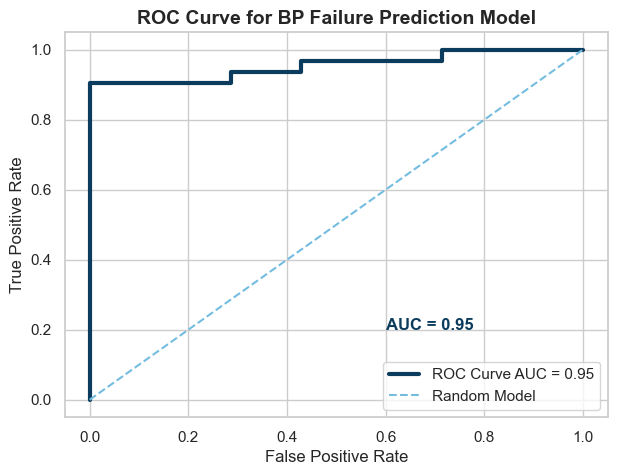

In [20]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, color="#0B3C5D", linewidth=3, label=f"ROC Curve AUC = {auc_score:.2f}")
plt.plot([0, 1], [0, 1], color="#74BDE0", linestyle="--", label="Random Model")

plt.title("ROC Curve for BP Failure Prediction Model", fontsize=14, fontweight="bold")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.text(0.6, 0.2, f"AUC = {auc_score:.2f}", fontsize=12, fontweight="bold", color="#0B3C5D")

plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_8852\96819266.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
C:\Users\User\AppData\Local\Temp\ipykernel_8852\96819266.py:6: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  ax = sns.barplot(


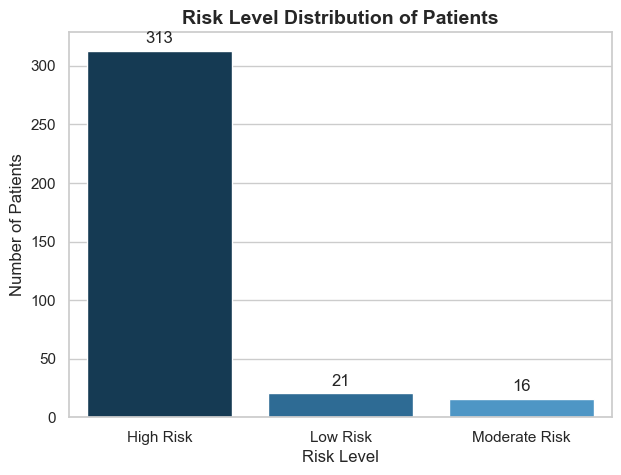

In [21]:
risk_count = df["Risk_Level"].value_counts().reset_index()
risk_count.columns = ["Risk_Level", "Patient_Count"]

plt.figure(figsize=(7,5))

ax = sns.barplot(
    data=risk_count,
    x="Risk_Level",
    y="Patient_Count",
    palette=blue_palette
)

plt.title("Risk Level Distribution of Patients", fontsize=14, fontweight="bold")
plt.xlabel("Risk Level")
plt.ylabel("Number of Patients")

for container in ax.containers:
    ax.bar_label(container, fmt="%d", label_type="edge", padding=3)

plt.show()

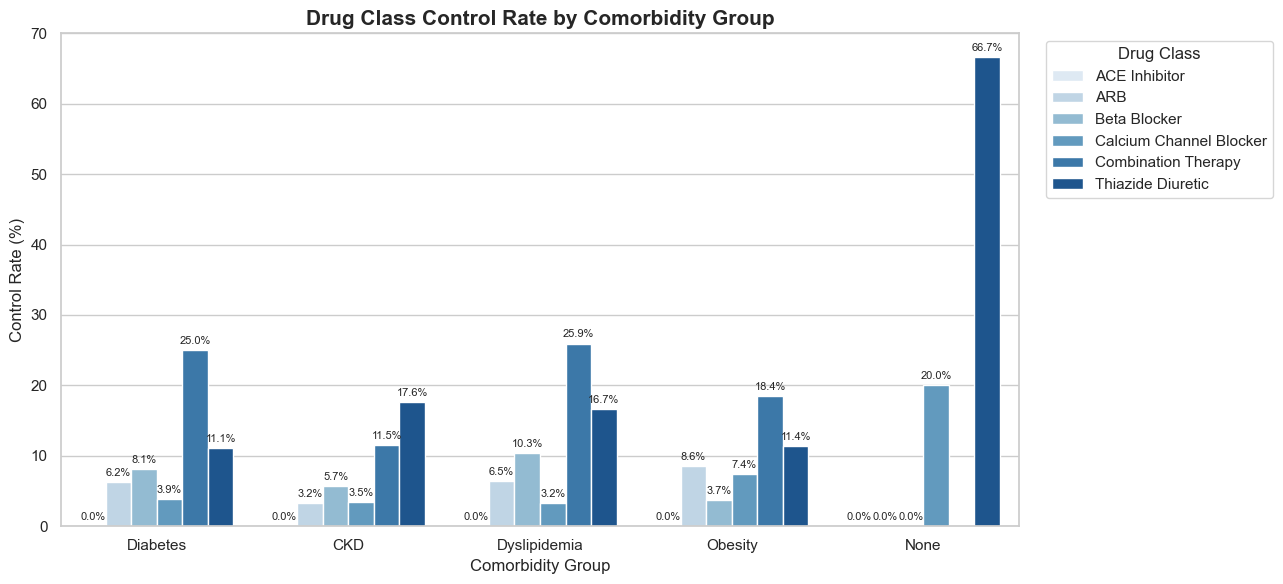

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Recreate the SQL style result
comorbidity_long = []

conditions = {
    "Diabetes": "Diabetes_Mellitus",
    "CKD": "Chronic_Kidney_Disease",
    "Dyslipidemia": "Dyslipidemia",
    "Obesity": "Obesity"
}

for group_name, col in conditions.items():
    temp = df[df[col] == "Yes"].groupby("Antihypertensive_Class").agg(
        total_patients=("Patient_ID", "count"),
        controlled=("BP_Controlled_After_3_Months", lambda x: (x == "Yes").sum())
    ).reset_index()
    
    temp["Comorbidity_Group"] = group_name
    temp["Control_Rate"] = (temp["controlled"] * 100 / temp["total_patients"]).round(2)
    comorbidity_long.append(temp)

# Add patients with no comorbidity
none_temp = df[
    (df["Diabetes_Mellitus"] == "No") &
    (df["Chronic_Kidney_Disease"] == "No") &
    (df["Dyslipidemia"] == "No") &
    (df["Obesity"] == "No")
].groupby("Antihypertensive_Class").agg(
    total_patients=("Patient_ID", "count"),
    controlled=("BP_Controlled_After_3_Months", lambda x: (x == "Yes").sum())
).reset_index()

none_temp["Comorbidity_Group"] = "None"
none_temp["Control_Rate"] = (none_temp["controlled"] * 100 / none_temp["total_patients"]).round(2)

comorbidity_long.append(none_temp)

comorbidity_chart = pd.concat(comorbidity_long, ignore_index=True)

# Plot clustered bar chart
plt.figure(figsize=(13, 6))

ax = sns.barplot(
    data=comorbidity_chart,
    x="Comorbidity_Group",
    y="Control_Rate",
    hue="Antihypertensive_Class",
    palette="Blues"
)

plt.title("Drug Class Control Rate by Comorbidity Group", fontsize=15, fontweight="bold")
plt.xlabel("Comorbidity Group", fontsize=12)
plt.ylabel("Control Rate (%)", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="Drug Class", bbox_to_anchor=(1.02, 1), loc="upper left")

# Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="edge", padding=3, fontsize=8)

plt.tight_layout()
plt.show()

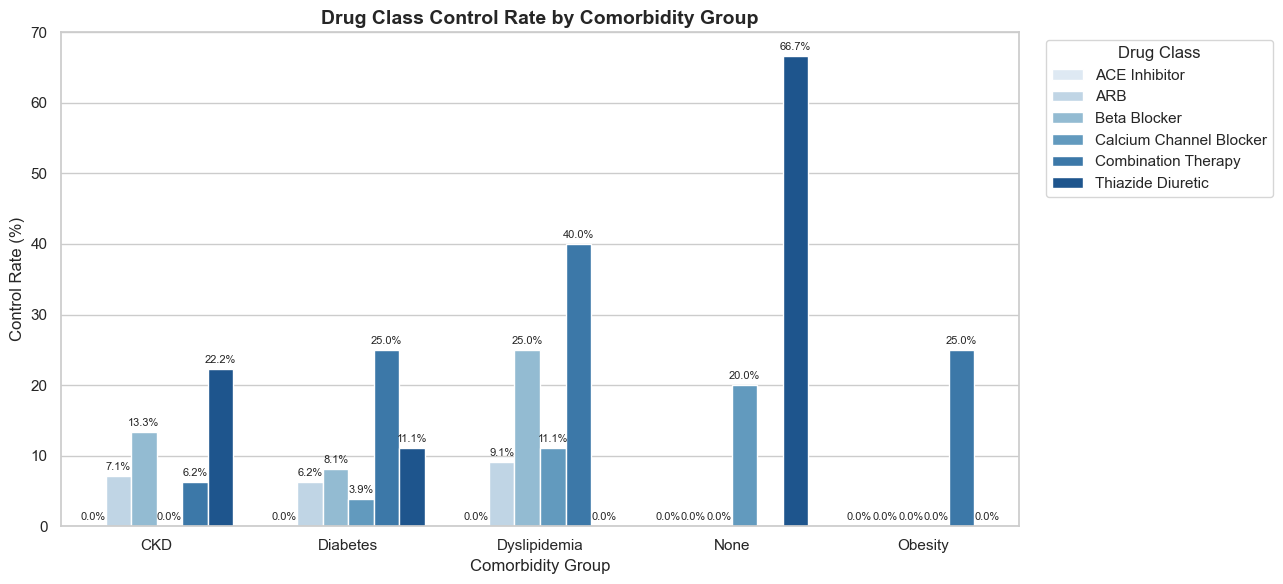

,Comorbidity_Group,Antihypertensive_Class,total_patients,controlled,control_rate
5,CKD,Thiazide Diuretic,9,2,22.22
2,CKD,Beta Blocker,15,2,13.33
1,CKD,ARB,14,1,7.14
4,CKD,Combination Therapy,16,1,6.25
0,CKD,ACE Inhibitor,17,0,0.00
3,CKD,Calcium Channel Blocker,15,0,0.00
10,Diabetes,Combination Therapy,32,8,25.00
11,Diabetes,Thiazide Diuretic,36,4,11.11
8,Diabetes,Beta Blocker,37,3,8.11
7,Diabetes,ARB,32,2,6.25


In [23]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

conditions = [
    df["Diabetes_Mellitus"] == "Yes",
    df["Chronic_Kidney_Disease"] == "Yes",
    df["Dyslipidemia"] == "Yes",
    df["Obesity"] == "Yes"
]

choices = ["Diabetes", "CKD", "Dyslipidemia", "Obesity"]

df["Comorbidity_Group"] = np.select(conditions, choices, default="None")

chart_df = df.groupby(
    ["Comorbidity_Group", "Antihypertensive_Class"]
).agg(
    total_patients=("Patient_ID", "count"),
    controlled=("BP_Controlled_After_3_Months", lambda x: (x == "Yes").sum())
).reset_index()

chart_df["control_rate"] = (
    chart_df["controlled"] * 100 / chart_df["total_patients"]
).round(2)

plt.figure(figsize=(13,6))

ax = sns.barplot(
    data=chart_df,
    x="Comorbidity_Group",
    y="control_rate",
    hue="Antihypertensive_Class",
    palette="Blues"
)

plt.title("Drug Class Control Rate by Comorbidity Group", fontsize=14, fontweight="bold")
plt.xlabel("Comorbidity Group")
plt.ylabel("Control Rate (%)")
plt.legend(title="Drug Class", bbox_to_anchor=(1.02, 1), loc="upper left")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3, fontsize=8)

plt.tight_layout()
plt.show()

chart_df.sort_values(["Comorbidity_Group", "control_rate"], ascending=[True, False])

In [24]:
import pandas as pd

df["Comorbidity_Profile"] = (
    "DM:" + df["Diabetes_Mellitus"] +
    " | CKD:" + df["Chronic_Kidney_Disease"] +
    " | Dys:" + df["Dyslipidemia"] +
    " | Obs:" + df["Obesity"]
)

profile_df = df.groupby(
    ["Comorbidity_Profile", "Antihypertensive_Class"]
).agg(
    total_patients=("Patient_ID", "count"),
    controlled_patients=("BP_Controlled_After_3_Months", lambda x: (x == "Yes").sum())
).reset_index()

profile_df["control_rate"] = (
    profile_df["controlled_patients"] * 100 / profile_df["total_patients"]
).round(2)

max_rate = profile_df.groupby("Comorbidity_Profile")["control_rate"].max().reset_index()
max_rate = max_rate.rename(columns={"control_rate": "max_rate"})

best_drug = profile_df.merge(max_rate, on="Comorbidity_Profile")
best_drug = best_drug[best_drug["control_rate"] == best_drug["max_rate"]]

best_drug["Best_Drug_Class"] = best_drug.apply(
    lambda row: "No Effective Drug" if row["max_rate"] == 0 else row["Antihypertensive_Class"],
    axis=1
)

final_table = best_drug[
    [
        "Comorbidity_Profile",
        "Best_Drug_Class",
        "total_patients",
        "controlled_patients",
        "control_rate"
    ]
].rename(columns={
    "Comorbidity_Profile": "Comorbidity Profile",
    "Best_Drug_Class": "Best Drug Class",
    "total_patients": "Total Patients",
    "controlled_patients": "Controlled Patients",
    "control_rate": "Control Rate (%)"
})

final_table

,Comorbidity Profile,Best Drug Class,Total Patients,Controlled Patients,Control Rate (%)
4,DM:No | CKD:No | Dys:No | Obs:No,Thiazide Diuretic,3,2,66.67
9,DM:No | CKD:No | Dys:No | Obs:Yes,Combination Therapy,4,1,25.00
15,DM:No | CKD:No | Dys:Yes | Obs:No,Combination Therapy,2,2,100.00
20,DM:No | CKD:No | Dys:Yes | Obs:Yes,Calcium Channel Blocker,4,1,25.00
25,DM:No | CKD:Yes | Dys:No | Obs:No,Beta Blocker,5,1,20.00
34,DM:No | CKD:Yes | Dys:No | Obs:Yes,Thiazide Diuretic,4,1,25.00
37,DM:No | CKD:Yes | Dys:Yes | Obs:No,Beta Blocker,5,1,20.00
46,DM:No | CKD:Yes | Dys:Yes | Obs:Yes,Thiazide Diuretic,1,1,100.00
48,DM:Yes | CKD:No | Dys:No | Obs:No,ARB,3,1,33.33
51,DM:Yes | CKD:No | Dys:No | Obs:No,Combination Therapy,3,1,33.33
